# Grey Matter Mask Inspection

Check fMRIPrep tissue probability maps and verify ROI coverage.
For each ROI: fraction of voxels above GM threshold + mean GM probability within the ROI.

In [3]:
from pathlib import Path

# ---------------------------------------------------------------------------
# Paths — adjust for your environment
# ---------------------------------------------------------------------------
FMRIPREP_DIR = Path("/mnt/data/learning-habits/bids_dataset/derivatives/fmriprep-24.0.1-noSDC")
MASK_DIR     = Path("/mnt/data/learning-habits/masks/MNI152NLin2009cAsym")

# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
GM_THRESHOLD = 0.3   # GM probability threshold for binarising the mask

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import image, plotting

# --- Load pre-made ROI masks (already in MNI152NLin2009cAsym space) ---
roi_masks = {}
for mask_file in sorted(MASK_DIR.glob("*.nii*")):
    roi_name = mask_file.name.replace("_MNI152NLin2009cAsym.nii.gz", "").replace("_MNI152NLin2009cAsym.nii", "")
    img = nib.load(mask_file)
    # Squeeze singleton 4th dimension if present
    if img.ndim == 4 and img.shape[3] == 1:
        img = image.index_img(img, 0)
    roi_masks[roi_name] = img
    print(f"{roi_name}: shape={img.shape}, zooms={img.header.get_zooms()[:3]}")

print(f"\n{len(roi_masks)} ROI masks loaded from {MASK_DIR}")

fusiform_mask: shape=(91, 109, 91), zooms=(2.0, 2.0, 2.0)
glm_chosen_peaks_spheres6mm: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
habit_Guida2022: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
motor_HMAT: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
motor_M1only_HMAT: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
parietal_AAL: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
premotor_HMAT: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
putamen_AAL: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
striatum_bartra2013: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)
vmpfc_bartra2013: shape=(53, 65, 48), zooms=(3.0, 3.0, 3.5)

10 ROI masks loaded from /mnt/data/learning-habits/masks/MNI152NLin2009cAsym


## Load fMRIPrep GM probability maps

In [6]:
gm_files = sorted(FMRIPREP_DIR.glob(
    "sub-*/ses-1/anat/sub-*_ses-1_run-1_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz"
))
print(f"Found {len(gm_files)} GM probability maps")

# Load and stack into a 4D array (x, y, z, subjects)
ref_img   = nib.load(gm_files[0])
gm_stack  = np.stack([nib.load(f).get_fdata(dtype=np.float32) for f in gm_files], axis=-1)
subjects  = [f.parts[-4] for f in gm_files]   # 'sub-XX'

print(f"Stack shape: {gm_stack.shape}")
print(f"Value range: [{gm_stack.min():.2f}, {gm_stack.max():.2f}]")

Found 71 GM probability maps
Stack shape: (193, 229, 193, 71)
Value range: [0.00, 1.00]


## Group-average GM map

In [10]:
gm_mean_img = image.new_img_like(ref_img, gm_stack.mean(axis=-1))

## ROI coverage at threshold

For each subject and ROI: fraction of ROI voxels with GM probability > `GM_THRESHOLD`, and mean GM probability within the ROI.

In [11]:
records = []

for roi_name, roi_img in roi_masks.items():
    roi_resampled = image.resample_to_img(roi_img, ref_img, interpolation='nearest')
    roi_mask = roi_resampled.get_fdata() > 0   # boolean (x, y, z)

    for i, sub in enumerate(subjects):
        gm_prob = gm_stack[..., i]
        gm_in_roi = gm_prob[roi_mask]
        records.append({
            'subject':          sub,
            'roi':              roi_name,
            'mean_gm_prob':     float(gm_in_roi.mean()),
            'coverage_frac':    float((gm_in_roi > GM_THRESHOLD).mean()),
            'n_roi_voxels':     int(roi_mask.sum()),
            'n_covered_voxels': int((gm_in_roi > GM_THRESHOLD).sum()),
        })

coverage = pd.DataFrame(records)
print(coverage.groupby('roi')[['mean_gm_prob', 'coverage_frac']].describe().round(3))

                            mean_gm_prob                                     \
                                   count   mean    std    min    25%    50%   
roi                                                                           
fusiform_mask                       71.0  0.559  0.048  0.436  0.528  0.561   
glm_chosen_peaks_spheres6mm         71.0  0.280  0.093  0.107  0.211  0.267   
habit_Guida2022                     71.0  0.232  0.033  0.161  0.211  0.230   
motor_HMAT                          71.0  0.332  0.022  0.273  0.320  0.329   
motor_M1only_HMAT                   71.0  0.292  0.020  0.249  0.278  0.290   
parietal_AAL                        71.0  0.376  0.028  0.317  0.359  0.372   
premotor_HMAT                       71.0  0.349  0.024  0.284  0.334  0.349   
putamen_AAL                         71.0  0.283  0.048  0.179  0.250  0.281   
striatum_bartra2013                 71.0  0.499  0.113  0.274  0.418  0.512   
vmpfc_bartra2013                    71.0  0.572  0.0

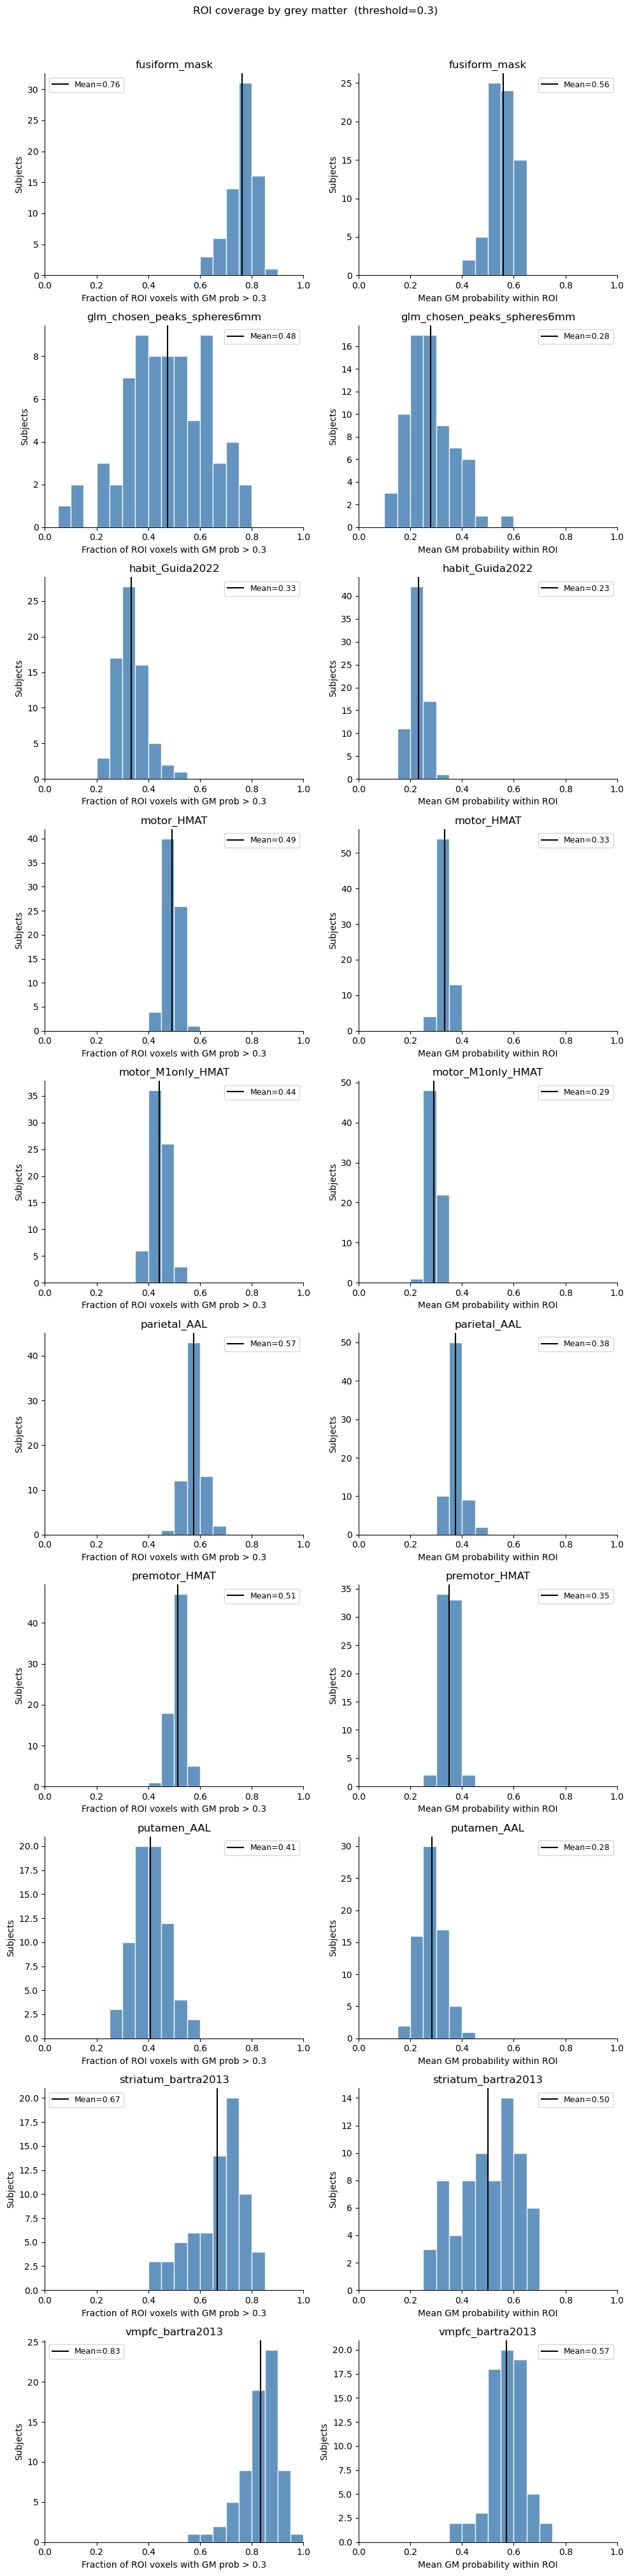

In [14]:
rois = coverage['roi'].unique()
fig, axes = plt.subplots(len(rois), 2, figsize=(10, 4 * len(rois)), squeeze=False)

BINS = np.linspace(0, 1, 21)   # 20 equal bins across [0, 1] for all panels

for row, roi_name in enumerate(rois):
    df_roi = coverage[coverage['roi'] == roi_name]

    for col, (metric, xlabel) in enumerate([
        ('coverage_frac', f'Fraction of ROI voxels with GM prob > {GM_THRESHOLD}'),
        ('mean_gm_prob',  'Mean GM probability within ROI'),
    ]):
        ax = axes[row, col]
        vals = df_roi[metric].values
        ax.hist(vals, bins=BINS, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(vals.mean(), color='black', linewidth=1.5, label=f'Mean={vals.mean():.2f}')
        ax.set_xlim(0, 1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Subjects')
        ax.set_title(roi_name)
        ax.legend(fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f"ROI coverage by grey matter  (threshold={GM_THRESHOLD})", y=1.01)
plt.tight_layout()
plt.show()

## Per-subject coverage (sorted)

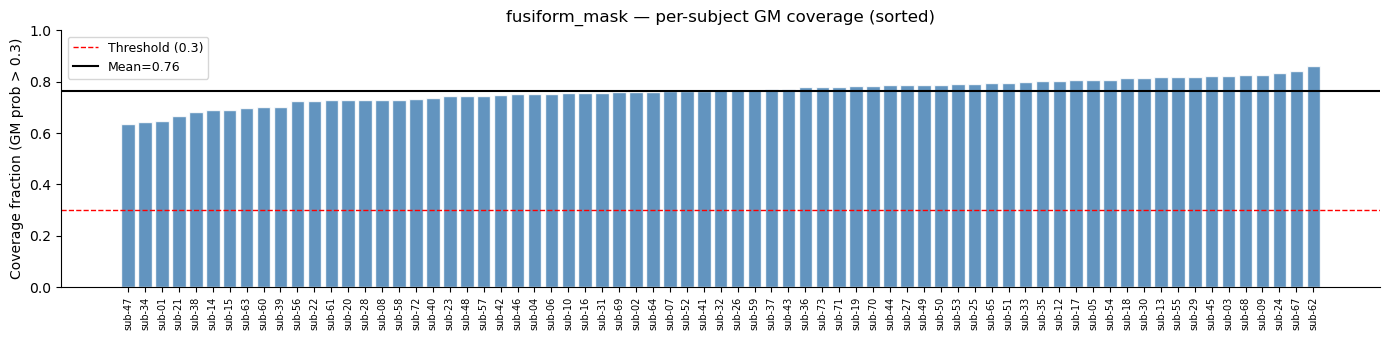

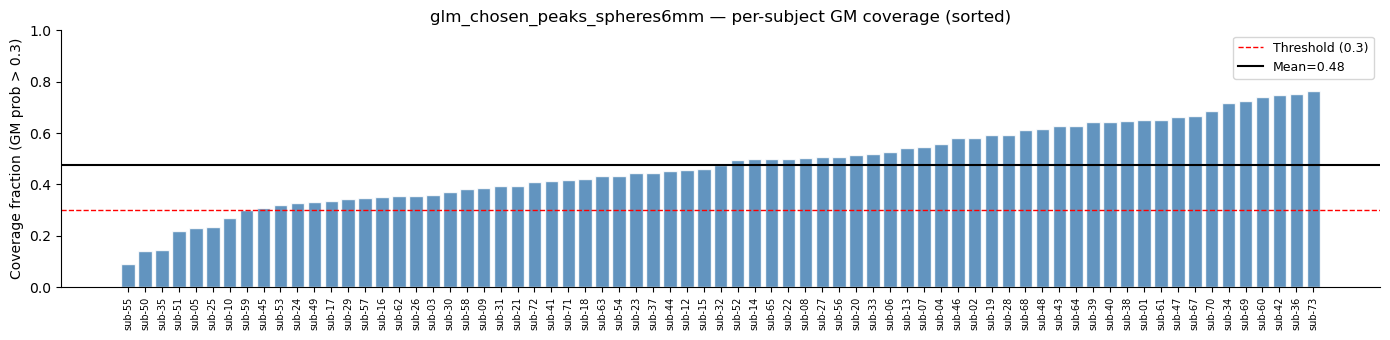

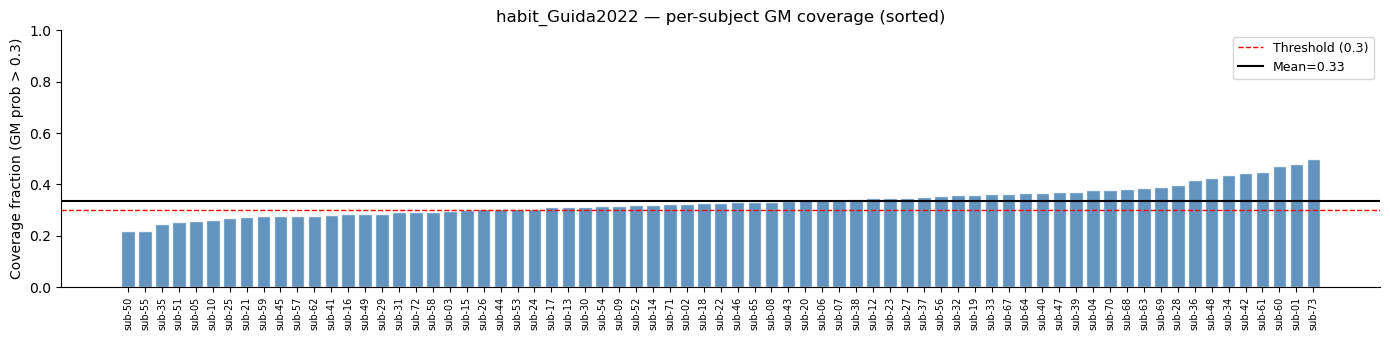

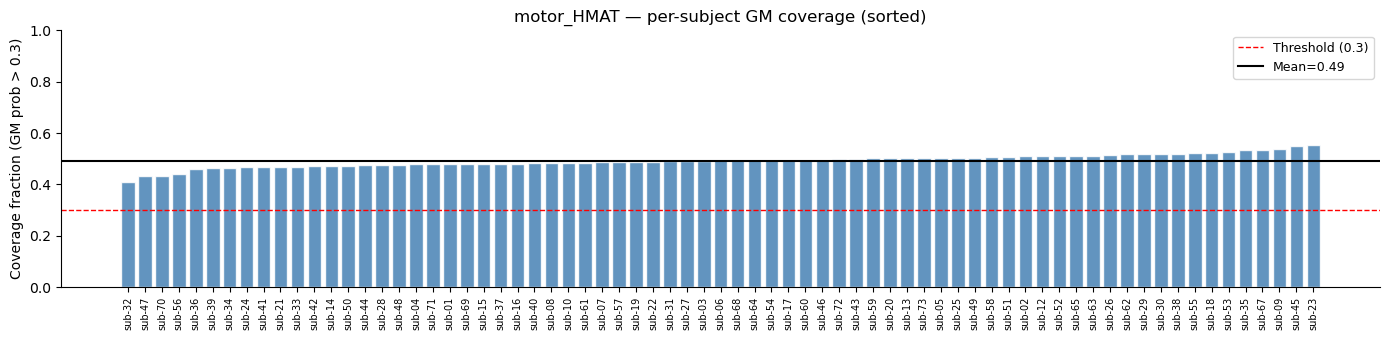

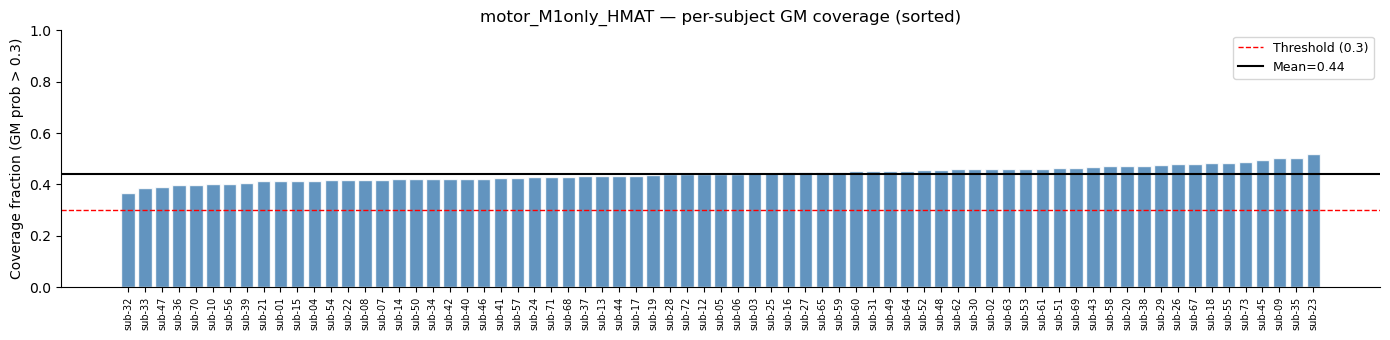

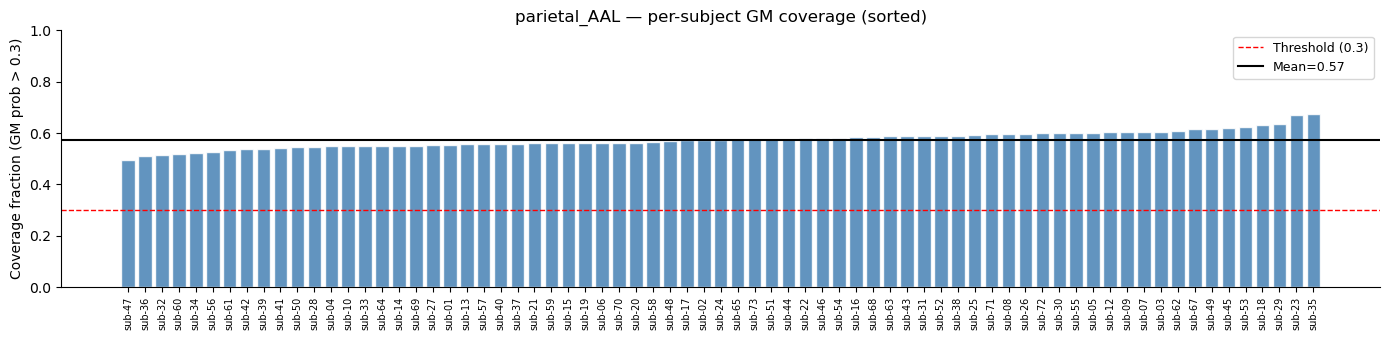

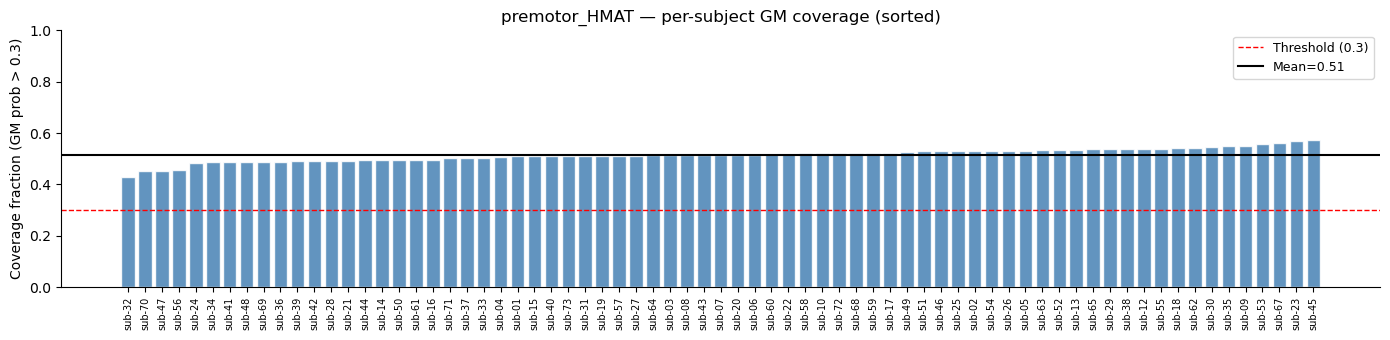

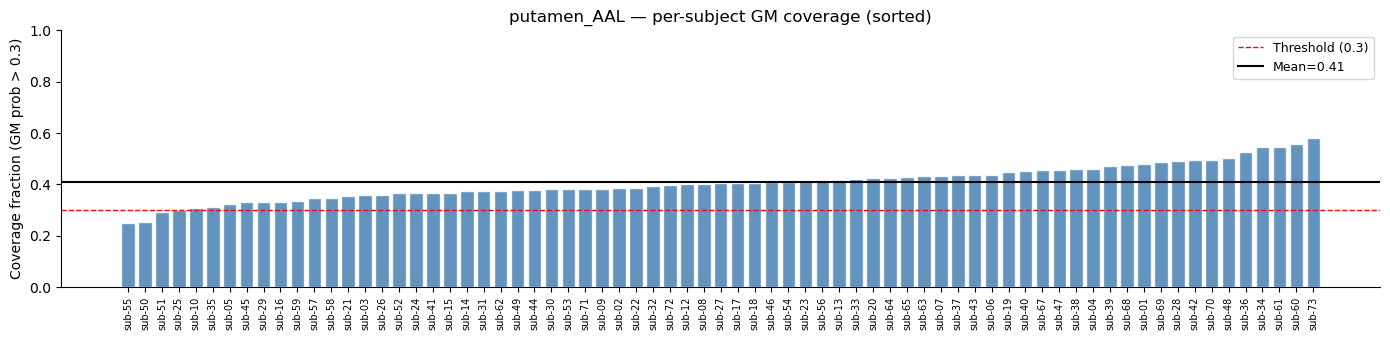

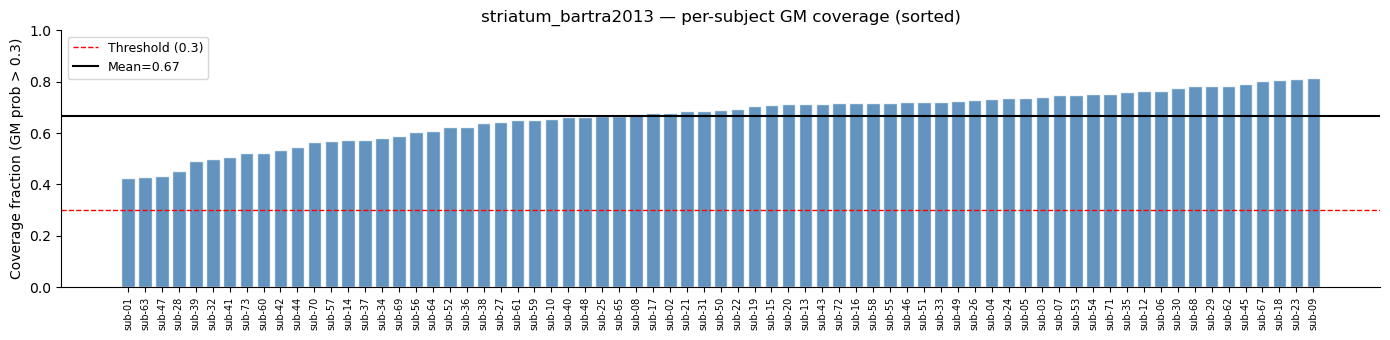

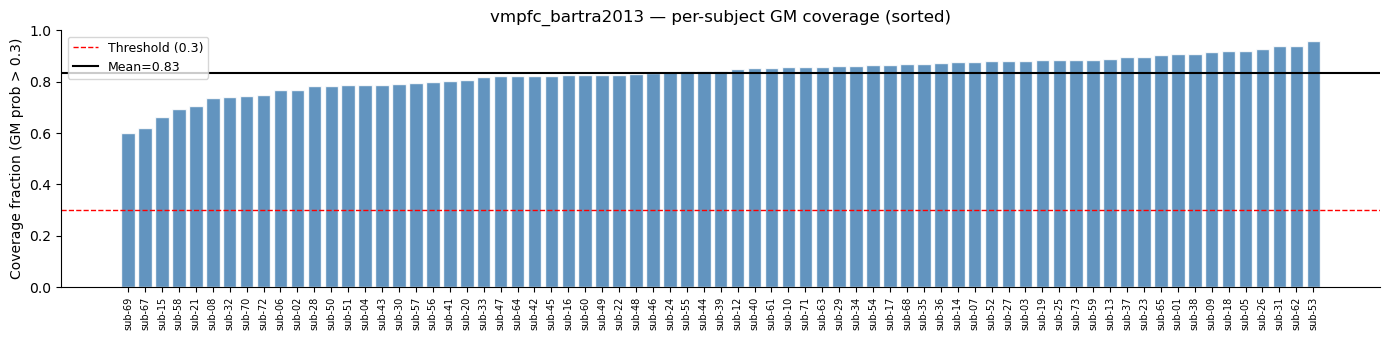

In [16]:
for roi_name in rois:
    df_roi = coverage[coverage['roi'] == roi_name].sort_values('coverage_frac')

    fig, ax = plt.subplots(figsize=(14, 3.5))
    x = np.arange(len(df_roi))
    bars = ax.bar(x, df_roi['coverage_frac'], color='steelblue', alpha=0.85, edgecolor='white')
    ax.axhline(GM_THRESHOLD, color='red', linestyle='--', linewidth=1,
               label=f'Threshold ({GM_THRESHOLD})')
    ax.axhline(df_roi['coverage_frac'].mean(), color='black', linestyle='-', linewidth=1.5,
               label=f"Mean={df_roi['coverage_frac'].mean():.2f}")
    ax.set_xticks(x)
    ax.set_xticklabels(df_roi['subject'], rotation=90, fontsize=7)
    ax.set_ylabel(f'Coverage fraction (GM prob > {GM_THRESHOLD})')
    ax.set_ylim(0, 1)
    ax.set_title(f'{roi_name} — per-subject GM coverage (sorted)')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    # low = df_roi[df_roi['coverage_frac'] < 0.5]
    # if len(low):
    #     print(f"Subjects with <50% coverage in {roi_name}:")
    #     print(low[['subject', 'coverage_frac', 'mean_gm_prob']].to_string(index=False))
    # else:
    #     print(f"All subjects have ≥50% coverage in {roi_name}.")

## Threshold sensitivity

How coverage fraction changes as a function of the GM threshold.

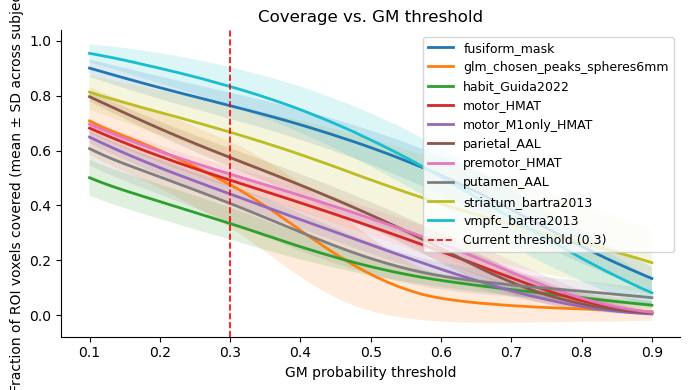

In [17]:
thresholds = np.linspace(0.1, 0.9, 50)
fig, ax = plt.subplots(figsize=(7, 4))

for roi_name, roi_img in roi_masks.items():
    roi_resampled = image.resample_to_img(roi_img, ref_img, interpolation='nearest')
    roi_mask = roi_resampled.get_fdata() > 0
    gm_in_roi = gm_stack[roi_mask, :]   # (n_roi_voxels, n_subjects)

    mean_coverage = [(gm_in_roi > t).mean(axis=0).mean() for t in thresholds]
    std_coverage  = [(gm_in_roi > t).mean(axis=0).std()  for t in thresholds]

    mean_coverage = np.array(mean_coverage)
    std_coverage  = np.array(std_coverage)

    ax.plot(thresholds, mean_coverage, label=roi_name, linewidth=2)
    ax.fill_between(thresholds,
                    mean_coverage - std_coverage,
                    mean_coverage + std_coverage,
                    alpha=0.15)

ax.axvline(GM_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'Current threshold ({GM_THRESHOLD})')
ax.set_xlabel('GM probability threshold')
ax.set_ylabel('Fraction of ROI voxels covered (mean ± SD across subjects)')
ax.set_title('Coverage vs. GM threshold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()